In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import imageio
import glob
import os

In [2]:
# load the dataset
ds = xr.open_dataset('./wrfout_d01_2026-03-20_06:00:00')

In [3]:
# TEMPERATURE
temp = ds.T2.isel(Time=0) - 273.15  # Convert from Kelvin to Celsius
lon = ds.XLONG.isel(Time=0)
lat = ds.XLAT.isel(Time=0)

/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


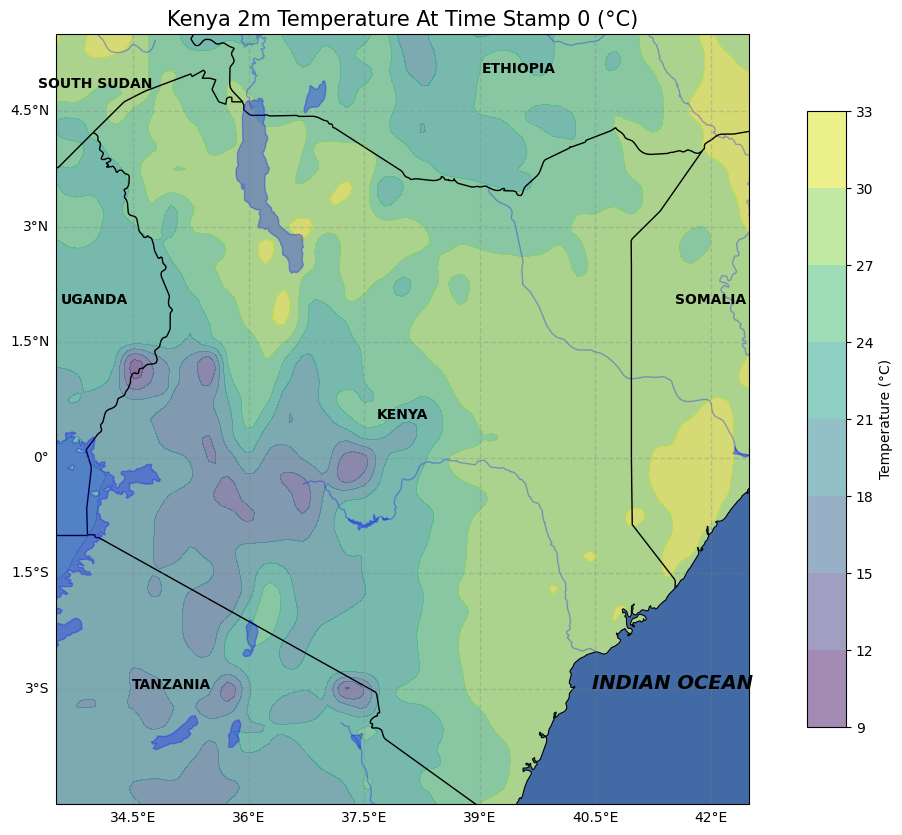

In [4]:
# PLOTTING 2m TEMPERATURE
fig = plt.figure(figsize=(15,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([33.5, 42.5, -4.5, 5.5], crs=ccrs.PlateCarree())  # Set the extent to cover Kenya

# ploting temperature as a filled contour
cp = plt.contourf(lon, lat, temp, transform=ccrs.PlateCarree(), cmap="viridis", alpha=0.5)

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="Blue")
ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)

# --- ADD GRIDLINES AND LABELS HERE ---
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

# Customize label appearance
gl.top_labels = False    # Turn off labels at the top
gl.right_labels = False  # Turn off labels on the right
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}
# -------------------------------------

# --- ADD COUNTRY AND OCEAN LABELS ---
# Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 10, 
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.5, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)

# Indian Ocean label (slightly tilted for style)
ax.text(41.5, -3.0, "INDIAN OCEAN", transform=ccrs.PlateCarree(),
        fontsize=14, fontstyle='italic', fontweight='bold', color='black', ha='center')

# Title and Colorbar
plt.title("Kenya 2m Temperature At Time Stamp 0 (°C)", fontsize=15)
plt.colorbar(cp, label="Temperature (°C)", orientation="vertical", pad=0.05, aspect=16, shrink=0.8)

plt.show()

In [ ]:
# Create an output directory for the frames
output_dir = "2m_temperature_maps"
os.makedirs(output_dir, exist_ok=True)

# Loop through all 25 time steps
for t in range(ds.dims['Time']):
    # 1. Extract data for the current time step
    temp = ds.T2.isel(Time=t) - 273.15  # Convert from Kelvin to Celsius
    lon = ds.XLONG.isel(Time=t)
    lat = ds.XLAT.isel(Time=t)
    
    # Get the timestamp string for titles and filenames
    time_str = str(ds.XTIME.values[t])[:19]
    
    # 2. Setup Figure
    fig = plt.figure(figsize=(20, 15))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([33.5, 42.5, -4.5, 5.5], crs=ccrs.PlateCarree())

    # 3. Emphasized Background (plt.contourf)
    # Using 'magma' or 'nipy_spectral' for punchy colors
    cp = plt.contourf(lon, lat, temp, transform=ccrs.PlateCarree(), cmap="viridis", alpha=0.5)


    # 4. Features and Labels
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="Blue")
    ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
    ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue",alpha=0.3)
    
    # Gridlines and Labels
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, 
                      linewidth=1, color='gray', alpha=0.3, linestyle='--')
    
    # Customize label appearance
    gl.top_labels = False    # Turn off labels at the top
    gl.right_labels = False  # Turn off labels on the right
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}


    # --- ADD COUNTRY AND OCEAN LABELS ---
    # Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
    common_style = {
        'transform': ccrs.PlateCarree(), 
        'fontsize': 10, 
        'fontweight': 'bold', 
        'ha': 'center'
    }

    ax.text(38.0, 0.5, "KENYA", **common_style)
    ax.text(42.0, 2.0, "SOMALIA", **common_style)
    ax.text(39.5, 5.0, "ETHIOPIA", **common_style)
    ax.text(34.0, 2.0, "UGANDA", **common_style)
    ax.text(35.0, -3.0, "TANZANIA", **common_style)
    ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)

    # Indian Ocean label (slightly tilted for style)
    ax.text(41.5, -3.0, "INDIAN OCEAN", transform=ccrs.PlateCarree(),
        fontsize=14, fontstyle='italic', fontweight='bold', color='black', ha='center')

    # Dynamic Title
    plt.title(f"Kenya 2m Temperature | {time_str}", fontsize=18, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(cp, orientation="vertical", pad=0.05, aspect=20, shrink=0.8)
    cbar.set_label("Temperature (°C)", weight='bold')

    # 6. Save and Close
    # Clean the time string for a filename
    file_name = f"temperature_map_t{t:02d}.png"
    plt.savefig(os.path.join(output_dir, file_name), bbox_inches='tight', dpi=150)
    
    plt.close(fig) # Critical to prevent memory overflow
    print(f"Finished plotting time step {t}: {time_str}")

/tmp/ipykernel_34869/3345093346.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t in range(ds.dims['Time']):
/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Finished plotting time step 0: 2026-03-20T06:00:00


/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Finished plotting time step 1: 2026-03-20T07:00:17


/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


...

Finished plotting time step 22: 2026-03-21T04:00:18


/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Finished plotting time step 23: 2026-03-21T05:00:35


/home/erickwambugu/METEOROLOGY_PYTHON/meteorologyvenv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Finished plotting time step 24: 2026-03-21T06:00:00


In [6]:
# 1. Get all the file paths in order
# Using sorted() is crucial to ensure t01 comes before t02
images = sorted(glob.glob(os.path.join(output_dir, "temperature_map_t*.png")))

# 2. Define output filename
output_video = "kenya_2m_temperature_animation.mp4"

# 3. Create the animation
with imageio.get_writer(output_video, fps=1) as writer: # Adjust fps for speed
    for filename in images:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"Animation saved successfully as {output_video}")

/tmp/ipykernel_34869/1721319606.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1913, 1833) to (1920, 1840) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x17f42e40] Stream #0: not enough frames to estimate rate; consider increasing probesize


Animation saved successfully as kenya_2m_temperature_animation.mp4
